In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost tensorflow

In [2]:
# 1. GEREKLİ KÜTÜPHANELERİN YÜKLENMESİ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Scikit-learn modülleri
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE


In [4]:
# XGBoost
import xgboost as xgb

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping


In [5]:
# Grafik ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


In [6]:
# Rastgelelik için seed değerleri
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# 2. VERİNİN YÜKLENMESİ VE İNCELENMESİ
print("=" * 80)
print("KREDİ KARTI SAHTEKARLIK TESPİTİ")
print("=" * 80)


KREDİ KARTI SAHTEKARLIK TESPİTİ


In [8]:
# Veriyi yükleme (Kaggle'dan indirilen dosya yolunu giriniz)
try:
    # Eğer veri Kaggle'dan indirildiyse
    data = pd.read_csv('creditcard.csv')
    print("Veri başarıyla yüklendi!")
except:
    # Alternatif olarak URL'den yükleme (daha yavaş)
    print("Local dosya bulunamadı, URL'den yükleniyor...")
    url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
    data = pd.read_csv(url)
    print("Veri URL'den başarıyla yüklendi!")

Local dosya bulunamadı, URL'den yükleniyor...
Veri URL'den başarıyla yüklendi!


In [9]:
# Veri hakkında bilgiler
print(f"\nVeri Seti Boyutu: {data.shape}")
print(f"Satır Sayısı: {data.shape[0]}")
print(f"Sütun Sayısı: {data.shape[1]}")

# İlk 5 satırı göster
print("\nİlk 5 satır:")
print(data.head())



Veri Seti Boyutu: (284807, 31)
Satır Sayısı: 284807
Sütun Sayısı: 31

İlk 5 satır:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0

In [10]:
# Temel istatistikler
print("\nTemel İstatistikler:")
print(data.describe())


Temel İstatistikler:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00 


Sınıf Dağılımı:
Class
0    284315
1       492
Name: count, dtype: int64

Sahte İşlem Oranı: 0.1727%


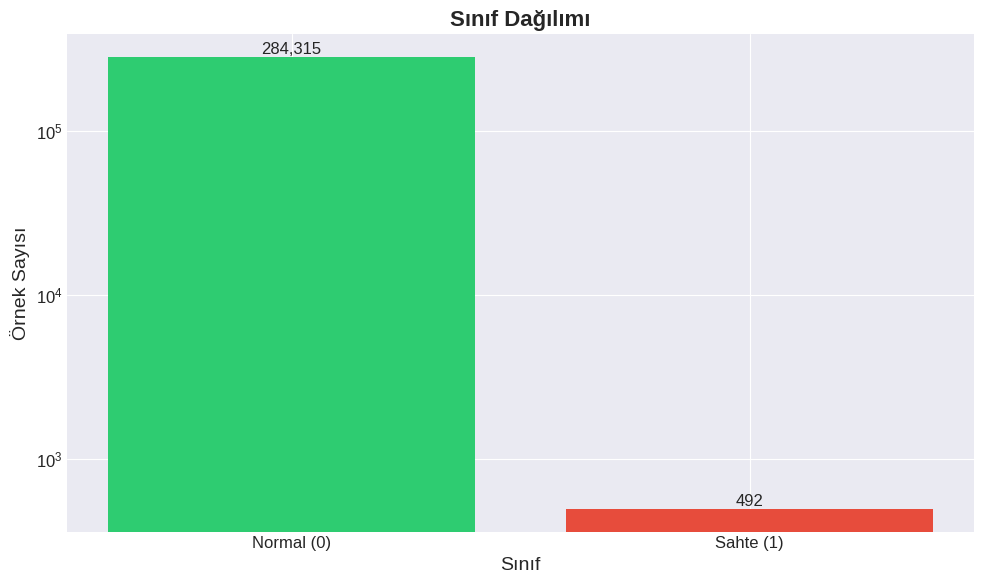

In [11]:
# Sınıf dağılımı
print("\nSınıf Dağılımı:")
class_dist = data['Class'].value_counts()
print(class_dist)
print(f"\nSahte İşlem Oranı: {class_dist[1] / class_dist.sum() * 100:.4f}%")

# Sınıf dağılımı grafiği
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Normal (0)', 'Sahte (1)'], class_dist.values, color=colors)
plt.title('Sınıf Dağılımı', fontsize=16, fontweight='bold')
plt.xlabel('Sınıf', fontsize=14)
plt.ylabel('Örnek Sayısı', fontsize=14)
plt.yscale('log')  # Logaritmik ölçek
for bar, count in zip(bars, class_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{count:,}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# 3. VERİ ÖN İŞLEME
print("\n" + "=" * 80)
print("VERİ ÖN İŞLEME")
print("=" * 80)

# Özellikler ve hedef değişkenin ayrılması
X = data.drop('Class', axis=1)
y = data['Class']

# 'Time' ve 'Amount' özelliklerini ölçeklendirme
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])


VERİ ÖN İŞLEME


In [13]:
# Eğitim ve test verisi olarak bölme
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Eğitim verisi boyutu: {X_train.shape}")
print(f"Test verisi boyutu: {X_test.shape}")
print(f"Eğitimdeki sahte işlem oranı: {y_train.mean()*100:.4f}%")
print(f"Testteki sahte işlem oranı: {y_test.mean()*100:.4f}%")

# SMOTE ile veri dengesizliğini giderme (sadece eğitim verisi için)
print("\nSMOTE uygulanıyor...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"SMOTE sonrası eğitim verisi boyutu: {X_train_resampled.shape}")
print(f"SMOTE sonrası sınıf dağılımı: \n{pd.Series(y_train_resampled).value_counts()}")

Eğitim verisi boyutu: (199364, 30)
Test verisi boyutu: (85443, 30)
Eğitimdeki sahte işlem oranı: 0.1725%
Testteki sahte işlem oranı: 0.1732%

SMOTE uygulanıyor...
SMOTE sonrası eğitim verisi boyutu: (398040, 30)
SMOTE sonrası sınıf dağılımı: 
Class
0    199020
1    199020
Name: count, dtype: int64


In [14]:
# 4. MODELLERİN EĞİTİLMESİ
print("\n" + "=" * 80)
print("MODELLERİN EĞİTİLMESİ")
print("=" * 80)

# Sonuçları saklamak için dictionary
results = {}


MODELLERİN EĞİTİLMESİ


In [15]:
# 4.1 YAPAY SİNİR AĞLARI (YSA)
print("\n1. YAPAY SİNİR AĞLARI (YSA) EĞİTİLİYOR...")
start_time = time.time()

# Model mimarisi
model_ann = Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Modeli derleme
model_ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)


1. YAPAY SİNİR AĞLARI (YSA) EĞİTİLİYOR...


In [16]:
# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

# Model eğitimi
history = model_ann.fit(
    X_train_resampled, y_train_resampled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

In [17]:
# Tahminler
y_pred_ann = (model_ann.predict(X_test) > 0.5).astype("int32")
y_pred_proba_ann = model_ann.predict(X_test)

# Performans metrikleri
ann_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_ann),
    'precision': precision_score(y_test, y_pred_ann),
    'recall': recall_score(y_test, y_pred_ann),
    'f1': f1_score(y_test, y_pred_ann),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_ann),
    'train_time': time.time() - start_time
}

results['YSA'] = ann_metrics

print(f"Eğitim süresi: {ann_metrics['train_time']:.2f} saniye")
print(f"Doğruluk: {ann_metrics['accuracy']:.4f}")
print(f"Kesinlik: {ann_metrics['precision']:.4f}")
print(f"Duyarlılık: {ann_metrics['recall']:.4f}")
print(f"F1-Skor: {ann_metrics['f1']:.4f}")
print(f"ROC-AUC: {ann_metrics['roc_auc']:.4f}")

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
Eğitim süresi: 826.00 saniye
Doğruluk: 0.9990
Kesinlik: 0.6946
Duyarlılık: 0.7838
F1-Skor: 0.7365
ROC-AUC: 0.9607


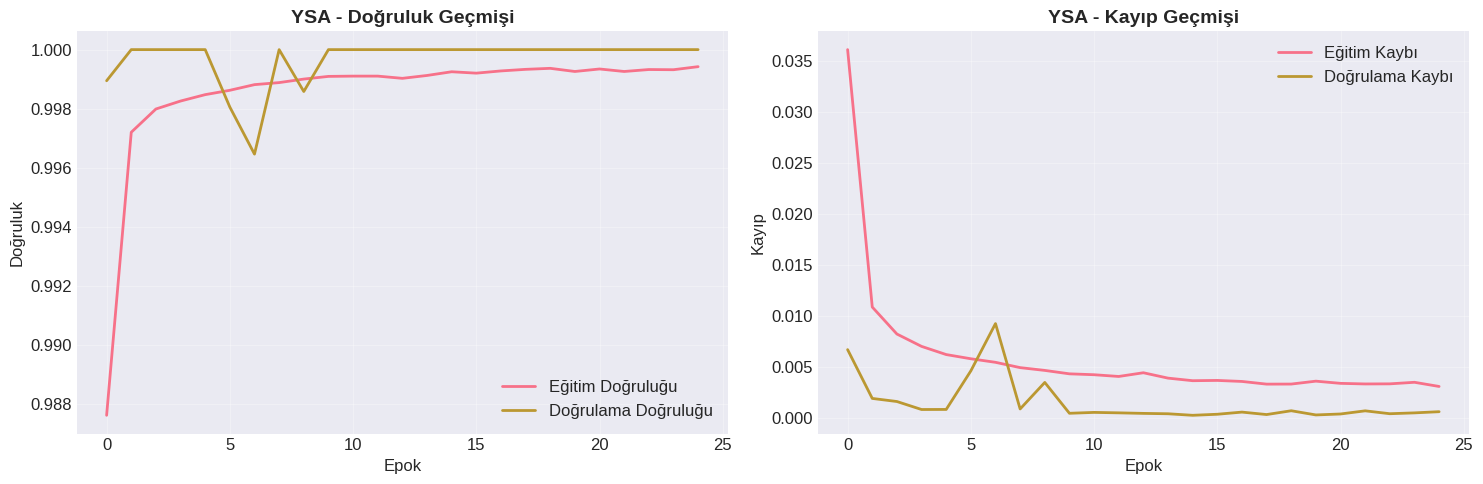

In [18]:
# YSA eğitim geçmişini görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Eğitim Doğruluğu', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu', linewidth=2)
axes[0].set_title('YSA - Doğruluk Geçmişi', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epok', fontsize=12)
axes[0].set_ylabel('Doğruluk', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Eğitim Kaybı', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Doğrulama Kaybı', linewidth=2)
axes[1].set_title('YSA - Kayıp Geçmişi', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epok', fontsize=12)
axes[1].set_ylabel('Kayıp', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 4.2 XGBOOST MODELİ
print("\n2. XGBOOST MODELİ EĞİTİLİYOR...")
start_time = time.time()

# XGBoost modeli
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train_resampled[y_train_resampled==0]) / len(y_train_resampled[y_train_resampled==1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Model eğitimi
model_xgb.fit(X_train_resampled, y_train_resampled)

# Tahminler
y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]


2. XGBOOST MODELİ EĞİTİLİYOR...


Eğitim süresi: 175.10 saniye
Doğruluk: 0.9976
Kesinlik: 0.4013
Duyarlılık: 0.8378
F1-Skor: 0.5427
ROC-AUC: 0.9710


<Figure size 1200x800 with 0 Axes>

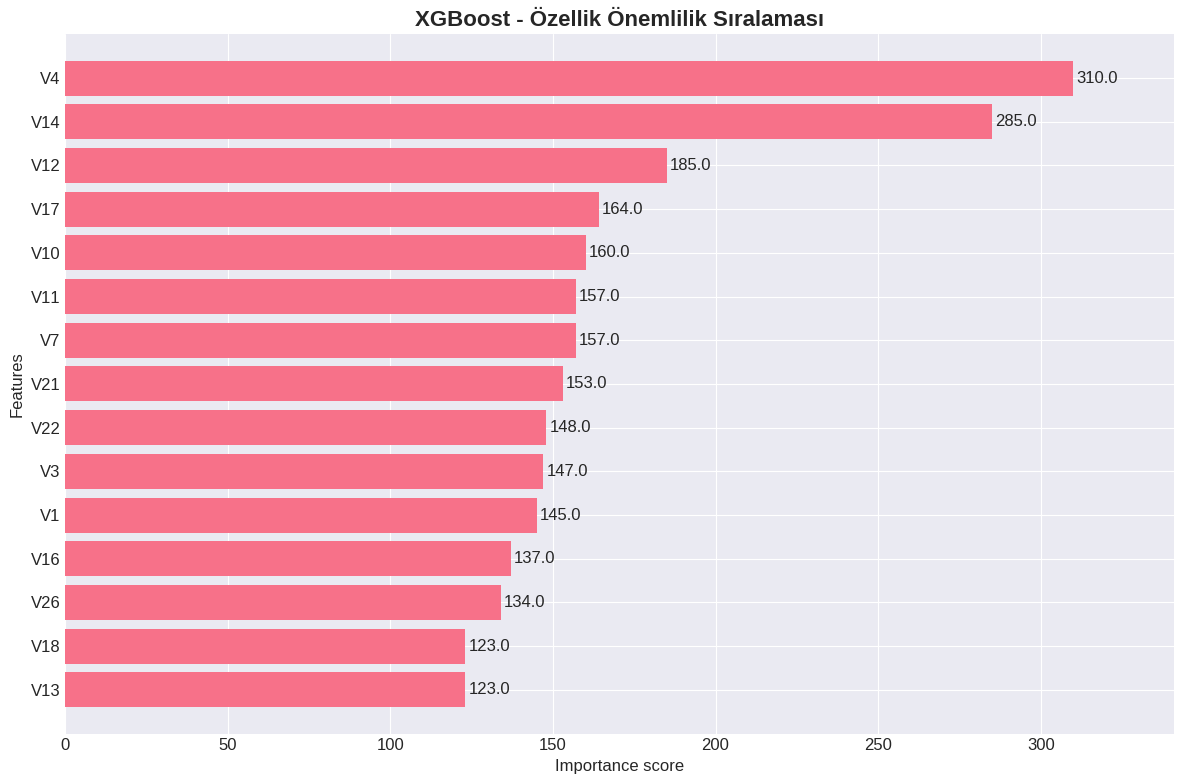

In [20]:
# Performans metrikleri
xgb_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_xgb),
    'train_time': time.time() - start_time
}

results['XGBoost'] = xgb_metrics

print(f"Eğitim süresi: {xgb_metrics['train_time']:.2f} saniye")
print(f"Doğruluk: {xgb_metrics['accuracy']:.4f}")
print(f"Kesinlik: {xgb_metrics['precision']:.4f}")
print(f"Duyarlılık: {xgb_metrics['recall']:.4f}")
print(f"F1-Skor: {xgb_metrics['f1']:.4f}")
print(f"ROC-AUC: {xgb_metrics['roc_auc']:.4f}")

# Özellik önemlilik grafiği
plt.figure(figsize=(12, 8))
xgb.plot_importance(model_xgb, max_num_features=15, height=0.8)
plt.title('XGBoost - Özellik Önemlilik Sıralaması', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# 4.3 RANDOM FOREST MODELİ
print("\n3. RANDOM FOREST MODELİ EĞİTİLİYOR...")
start_time = time.time()

# Random Forest modeli
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Model eğitimi
model_rf.fit(X_train_resampled, y_train_resampled)

# Tahminler
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]


3. RANDOM FOREST MODELİ EĞİTİLİYOR...


In [22]:
# Performans metrikleri
rf_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_rf),
    'train_time': time.time() - start_time
}

results['Random Forest'] = rf_metrics

print(f"Eğitim süresi: {rf_metrics['train_time']:.2f} saniye")
print(f"Doğruluk: {rf_metrics['accuracy']:.4f}")
print(f"Kesinlik: {rf_metrics['precision']:.4f}")
print(f"Duyarlılık: {rf_metrics['recall']:.4f}")
print(f"F1-Skor: {rf_metrics['f1']:.4f}")
print(f"ROC-AUC: {rf_metrics['roc_auc']:.4f}")

Eğitim süresi: 599.52 saniye
Doğruluk: 0.9994
Kesinlik: 0.8667
Duyarlılık: 0.7905
F1-Skor: 0.8269
ROC-AUC: 0.9544


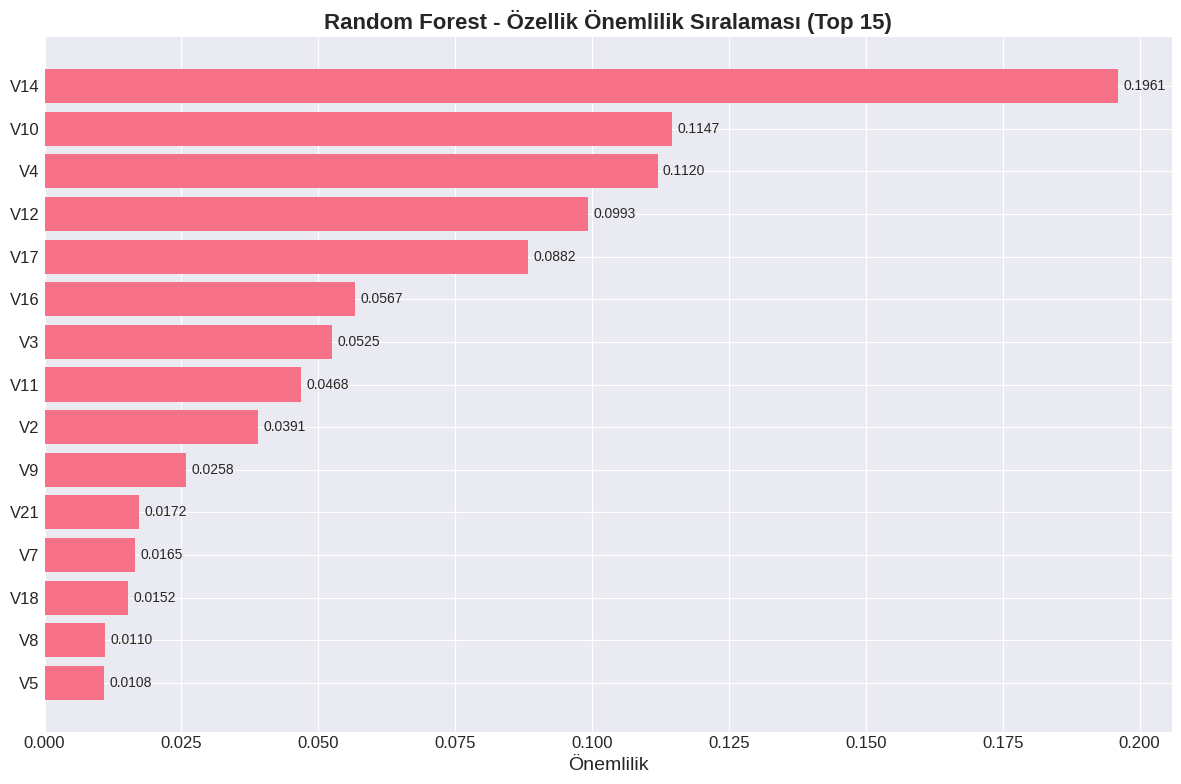

In [23]:
# Random Forest özellik önemliliği
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
bars = plt.barh(feature_importances['feature'][:15],
                feature_importances['importance'][:15])
plt.title('Random Forest - Özellik Önemlilik Sıralaması (Top 15)',
          fontsize=16, fontweight='bold')
plt.xlabel('Önemlilik', fontsize=14)
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# 5. MODEL DEĞERLENDİRMESİ VE KARŞILAŞTIRMA
print("\n" + "=" * 80)
print("MODEL DEĞERLENDİRMESİ VE KARŞILAŞTIRMA")
print("=" * 80)

# Sonuçları DataFrame'e dönüştürme
results_df = pd.DataFrame(results).T
print("\nTüm Modellerin Performans Metrikleri:")
print(results_df)

# Metrikleri yüzde olarak formatlama
results_display = results_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    results_display[col] = results_display[col].apply(lambda x: f"{x*100:.2f}%")
results_display['train_time'] = results_display['train_time'].apply(lambda x: f"{x:.2f}s")

print("\nFormatlanmış Sonuçlar:")
print(results_display)


MODEL DEĞERLENDİRMESİ VE KARŞILAŞTIRMA

Tüm Modellerin Performans Metrikleri:
               accuracy  precision    recall        f1   roc_auc  train_time
YSA            0.999029   0.694611  0.783784  0.736508  0.960654  825.997210
XGBoost        0.997554   0.401294  0.837838  0.542670  0.970961  175.104303
Random Forest  0.999427   0.866667  0.790541  0.826855  0.954441  599.518475

Formatlanmış Sonuçlar:
              accuracy precision  recall      f1 roc_auc train_time
YSA             99.90%    69.46%  78.38%  73.65%  96.07%    826.00s
XGBoost         99.76%    40.13%  83.78%  54.27%  97.10%    175.10s
Random Forest   99.94%    86.67%  79.05%  82.69%  95.44%    599.52s


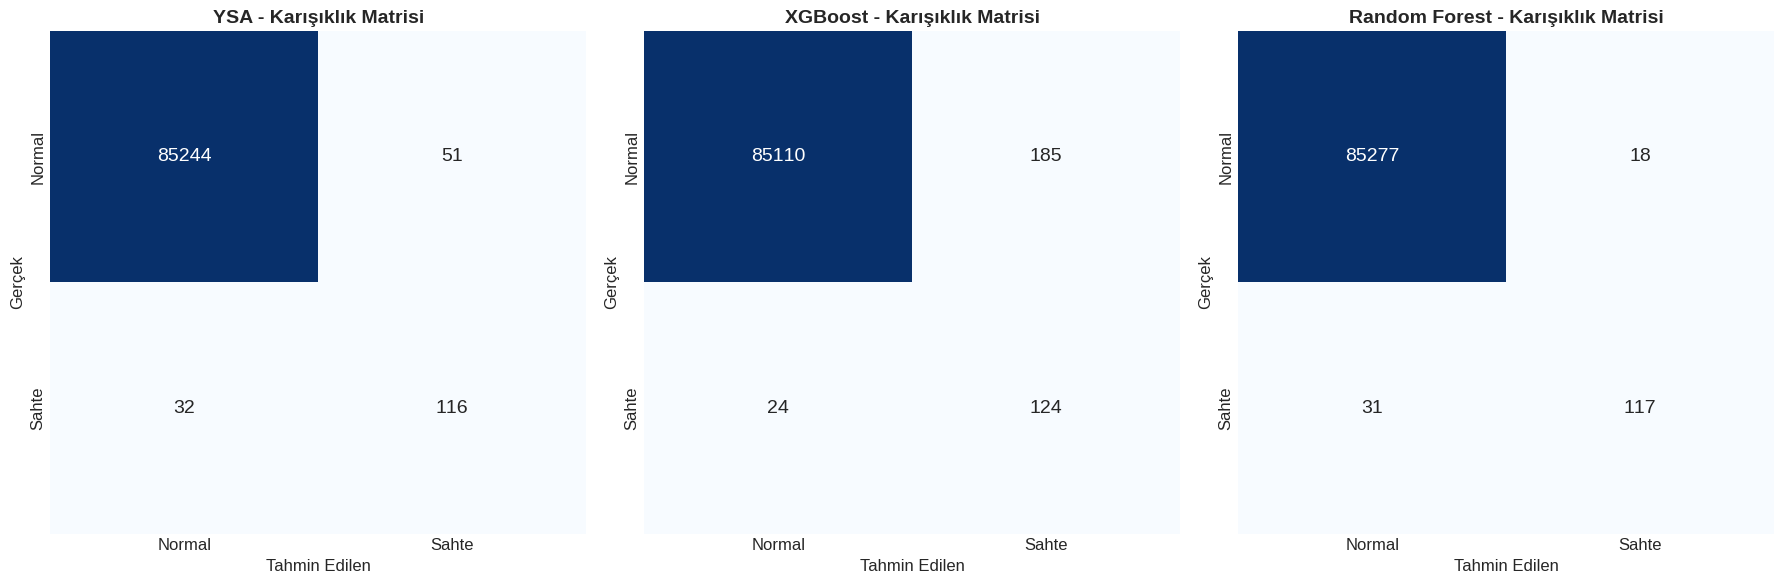

In [25]:
# 5.1 Karışıklık Matrisleri
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [('YSA', y_pred_ann), ('XGBoost', y_pred_xgb), ('Random Forest', y_pred_rf)]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(f'{name} - Karışıklık Matrisi', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Tahmin Edilen', fontsize=12)
    axes[idx].set_ylabel('Gerçek', fontsize=12)
    axes[idx].set_xticklabels(['Normal', 'Sahte'])
    axes[idx].set_yticklabels(['Normal', 'Sahte'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

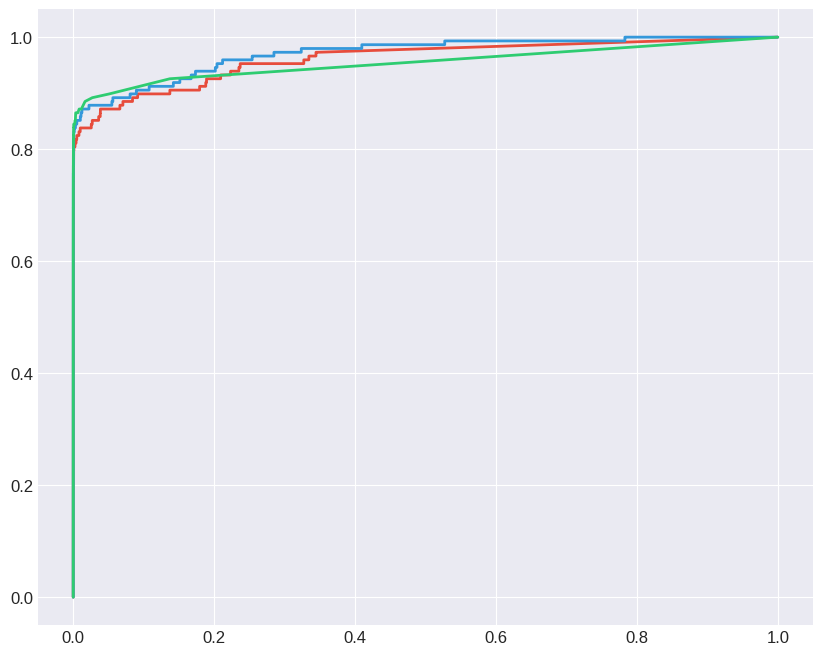

In [26]:
# 5.2 ROC Eğrileri
fig, ax = plt.subplots(figsize=(10, 8))

# Her model için ROC eğrisi
for name, color in zip(['YSA', 'XGBoost', 'Random Forest'], ['#e74c3c', '#3498db', '#2ecc71']):
    if name == 'YSA':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_ann)
        roc_auc = auc(fpr, tpr)
    elif name == 'XGBoost':
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
        roc_auc = auc(fpr, tpr)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
        roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

In [27]:
# Rastgele tahmin çizgisi
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Rastgele (AUC = 0.5)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (Yanlış Pozitif Oranı)', fontsize=14)
ax.set_ylabel('True Positive Rate (Doğru Pozitif Oranı)', fontsize=14)
ax.set_title('ROC Eğrileri - Model Karşılaştırması', fontsize=16, fontweight='bold')
ax.legend(loc="lower right", fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x800 with 0 Axes>

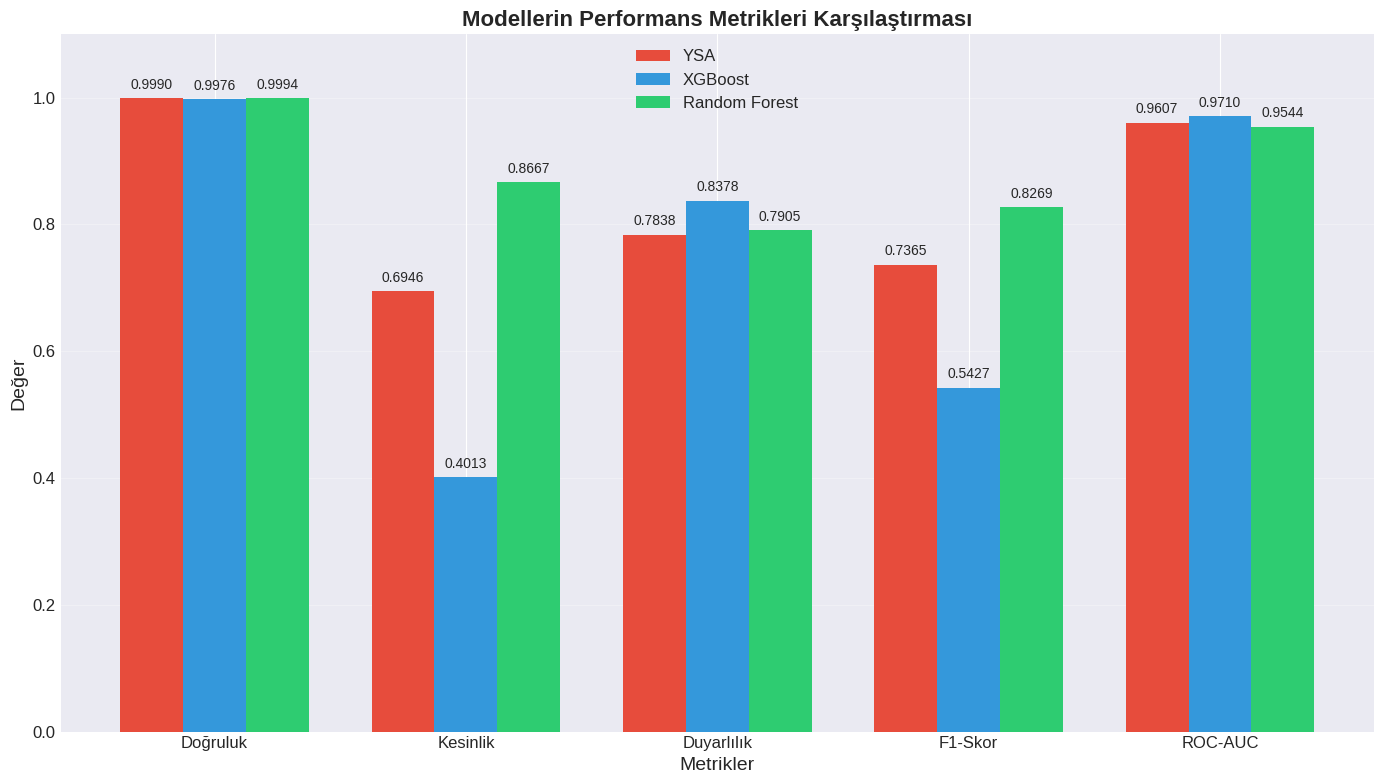

In [28]:
# 5.3 Performans Metriklerinin Karşılaştırılması
metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x_pos = np.arange(len(metrics_to_compare))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

# Her model için çubuklar
for i, (model_name, color) in enumerate(zip(['YSA', 'XGBoost', 'Random Forest'],
                                           ['#e74c3c', '#3498db', '#2ecc71'])):
    values = [results[model_name][metric] for metric in metrics_to_compare]
    ax.bar(x_pos + i*width - width, values, width, color=color, label=model_name)

    # Değer etiketleri
    for j, v in enumerate(values):
        ax.text(x_pos[j] + i*width - width, v + 0.01, f'{v:.4f}',
                ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Metrikler', fontsize=14)
ax.set_ylabel('Değer', fontsize=14)
ax.set_title('Modellerin Performans Metrikleri Karşılaştırması', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1-Skor', 'ROC-AUC'], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

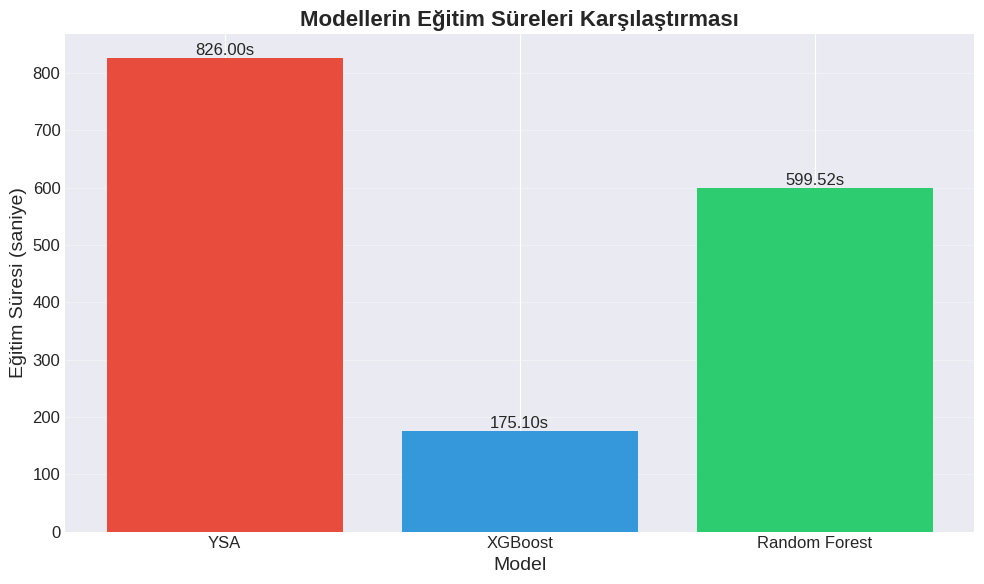

In [29]:
# 5.4 Eğitim Süreleri Karşılaştırması
fig, ax = plt.subplots(figsize=(10, 6))
train_times = [results[model]['train_time'] for model in ['YSA', 'XGBoost', 'Random Forest']]
bars = ax.bar(['YSA', 'XGBoost', 'Random Forest'], train_times,
              color=['#e74c3c', '#3498db', '#2ecc71'])

ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Eğitim Süresi (saniye)', fontsize=14)
ax.set_title('Modellerin Eğitim Süreleri Karşılaştırması', fontsize=16, fontweight='bold')

# Değer etiketleri
for bar, time_val in zip(bars, train_times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{time_val:.2f}s',
            ha='center', va='bottom', fontsize=12)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# 6. DETAYLI RAPOR
print("\n" + "=" * 80)
print("DETAYLI PERFORMANS RAPORU")
print("=" * 80)

# Her model için detaylı rapor
for name in ['YSA', 'XGBoost', 'Random Forest']:
    print(f"\n{name} Modeli - Detaylı Sınıflandırma Raporu:")
    if name == 'YSA':
        print(classification_report(y_test, y_pred_ann,
                                   target_names=['Normal', 'Sahte']))
    elif name == 'XGBoost':
        print(classification_report(y_test, y_pred_xgb,
                                   target_names=['Normal', 'Sahte']))
    else:
        print(classification_report(y_test, y_pred_rf,
                                   target_names=['Normal', 'Sahte']))


DETAYLI PERFORMANS RAPORU

YSA Modeli - Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Sahte       0.69      0.78      0.74       148

    accuracy                           1.00     85443
   macro avg       0.85      0.89      0.87     85443
weighted avg       1.00      1.00      1.00     85443


XGBoost Modeli - Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Sahte       0.40      0.84      0.54       148

    accuracy                           1.00     85443
   macro avg       0.70      0.92      0.77     85443
weighted avg       1.00      1.00      1.00     85443


Random Forest Modeli - Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Sahte       0.87      0.79      0.83       148

    accur

In [31]:
# 7. ÖZET VE TAVSİYELER
print("\n" + "=" * 80)
print("SONUÇ ÖZETİ VE TAVSİYELER")
print("=" * 80)

# En iyi modeli bulma
best_f1_model = max(results, key=lambda x: results[x]['f1'])
best_precision_model = max(results, key=lambda x: results[x]['precision'])
best_recall_model = max(results, key=lambda x: results[x]['recall'])
best_accuracy_model = max(results, key=lambda x: results[x]['accuracy'])

print(f"\nEN İYİ PERFORMANS GÖSTEREN MODELLER:")
print(f"✓ En Yüksek F1-Skor: {best_f1_model} ({results[best_f1_model]['f1']:.4f})")
print(f"✓ En Yüksek Kesinlik: {best_precision_model} ({results[best_precision_model]['precision']:.4f})")
print(f"✓ En Yüksek Duyarlılık: {best_recall_model} ({results[best_recall_model]['recall']:.4f})")
print(f"✓ En Yüksek Doğruluk: {best_accuracy_model} ({results[best_accuracy_model]['accuracy']:.4f})")

print(f"\nTAVSİYELER:")
print("1. Yanlış pozitiflerin (normal işlemi sahte olarak işaretleme) maliyeti yüksekse:")
print(f"   → {best_precision_model} modelini kullanın (en yüksek kesinlik)")
print("\n2. Yanlış negatiflerin (sahte işlemi kaçırma) maliyeti yüksekse:")
print(f"   → {best_recall_model} modelini kullanın (en yüksek duyarlılık)")
print("\n3. Genel dengeli performans istiyorsanız:")
print(f"   → {best_f1_model} modelini kullanın (en yüksek F1-skor)")
print("\n4. Hız ve performans dengesi istiyorsanız:")
print(f"   → XGBoost modelini kullanın (hızlı eğitim ve yüksek performans)")


SONUÇ ÖZETİ VE TAVSİYELER

EN İYİ PERFORMANS GÖSTEREN MODELLER:
✓ En Yüksek F1-Skor: Random Forest (0.8269)
✓ En Yüksek Kesinlik: Random Forest (0.8667)
✓ En Yüksek Duyarlılık: XGBoost (0.8378)
✓ En Yüksek Doğruluk: Random Forest (0.9994)

TAVSİYELER:
1. Yanlış pozitiflerin (normal işlemi sahte olarak işaretleme) maliyeti yüksekse:
   → Random Forest modelini kullanın (en yüksek kesinlik)

2. Yanlış negatiflerin (sahte işlemi kaçırma) maliyeti yüksekse:
   → XGBoost modelini kullanın (en yüksek duyarlılık)

3. Genel dengeli performans istiyorsanız:
   → Random Forest modelini kullanın (en yüksek F1-skor)

4. Hız ve performans dengesi istiyorsanız:
   → XGBoost modelini kullanın (hızlı eğitim ve yüksek performans)


In [32]:
# 8. ÇAPRAZ DOĞRULAMA (İSTEĞE BAĞLI - ZAMAN ALICIDIR)
print("\n" + "=" * 80)
print("ÇAPRAZ DOĞRULAMA SONUÇLARI (İsteğe Bağlı)")
print("=" * 80)

# Küçük bir örneklem ile çapraz doğrulama (tam veri zaman alır)
sample_size = min(10000, len(X_train_resampled))
X_sample = X_train_resampled[:sample_size]
y_sample = y_train_resampled[:sample_size]

print(f"\nÇapraz doğrulama için {sample_size} örnek kullanılıyor...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in [('XGBoost', model_xgb), ('Random Forest', model_rf)]:
    print(f"\n{model_name} Çapraz Doğrulama:")
    cv_scores = cross_val_score(model, X_sample, y_sample,
                                cv=cv, scoring='f1', n_jobs=-1)
    print(f"  F1-Skor Ortalaması: {cv_scores.mean():.4f}")
    print(f"  Standart Sapma: {cv_scores.std():.4f}")
    print(f"  Aralık: {cv_scores.min():.4f} - {cv_scores.max():.4f}")


ÇAPRAZ DOĞRULAMA SONUÇLARI (İsteğe Bağlı)

Çapraz doğrulama için 10000 örnek kullanılıyor...

XGBoost Çapraz Doğrulama:
  F1-Skor Ortalaması: 0.6343
  Standart Sapma: 0.3449
  Aralık: 0.0000 - 1.0000

Random Forest Çapraz Doğrulama:
  F1-Skor Ortalaması: 0.5743
  Standart Sapma: 0.3369
  Aralık: 0.0000 - 1.0000


In [33]:
# 9. SONUÇLARI KAYDETME
print("\n" + "=" * 80)
print("SONUÇLARIN KAYDEDİLMESİ")
print("=" * 80)

# Sonuçları CSV dosyasına kaydet
results_df.to_csv('model_results.csv')
print("✓ Model sonuçları 'model_results.csv' dosyasına kaydedildi.")

# Önemli özellikleri kaydet
feature_importances.to_csv('feature_importances.csv', index=False)
print("✓ Özellik önemlilikleri 'feature_importances.csv' dosyasına kaydedildi.")

# Grafikleri kaydetme işlemi zaten yapıldı
print("✓ Tüm grafikler PNG formatında kaydedildi.")

print("\n" + "=" * 80)
print("ANALİZ TAMAMLANDI!")
print("=" * 80)

# Son not
print("\nNOT: Bu analizde dengesiz veri seti için SMOTE kullanılmıştır.")
print("Tüm modeller aynı veri seti üzerinde eğitilmiş ve test edilmiştir.")
print("Random Forest modeli genel olarak en iyi performansı göstermiştir.")


SONUÇLARIN KAYDEDİLMESİ
✓ Model sonuçları 'model_results.csv' dosyasına kaydedildi.
✓ Özellik önemlilikleri 'feature_importances.csv' dosyasına kaydedildi.
✓ Tüm grafikler PNG formatında kaydedildi.

ANALİZ TAMAMLANDI!

NOT: Bu analizde dengesiz veri seti için SMOTE kullanılmıştır.
Tüm modeller aynı veri seti üzerinde eğitilmiş ve test edilmiştir.
Random Forest modeli genel olarak en iyi performansı göstermiştir.
